# PIDNet CRP and PCX — Post-Merge Layers

This notebook runs CRP analysis and produces CRP/PCX explanations for the four PIDNet post-merge layers. It uses the trained flood checkpoint and the plotting style from `pidnet.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import gc
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as transforms
from crp.concepts import ChannelConcept
from crp.helper import get_layer_names

REPO_ROOT = Path('/home/heydari/paper/Segmentation-and-Object-detection-PCX')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.datasets.flood_dataset import FloodDataset
from src.plot_crp_explanations import plot_explanations
from src.plot_pcx_pidnet_new import plot_pcx_explanations
from LCRP.models import get_model
from LCRP.utils.crp_configs import ATTRIBUTORS, CANONIZERS, VISUALIZATIONS, COMPOSITES

logging.getLogger('PIL').setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('numba').setLevel(logging.WARNING)

/home/heydari/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/heydari/.local/lib/python3.10/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (None)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


## Configuration

In [2]:
MODEL_NAME = 'pidnet'
CHECKPOINT = REPO_ROOT / 'LCRP/models/flood_model.pt'
DATA_ROOT = REPO_ROOT / 'flood_segmentation'
SPLIT = 'val'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

POST_MERGE_LAYERS = [
    'dfm.conv_p.0',
    'dfm.conv_i.0',
    # PIDNetCanonizer executes copied head convolutions through `sequential`.
    'final_layer.sequential.conv1',
    'final_layer.sequential.conv2',
]

CLASS_ID = 1
SAMPLE_ID = 10
N_CONCEPTS = 3
N_REFIMGS = 12
N_PROTOTYPES = 10
PREDICTION_NUM = 0
MODE = 'relevance'
CRP_BATCH_SIZE = 1
PCX_BATCH_SIZE = 1
RUN_CRP_ANALYSIS = True  # Set True once to build CRP maximization/statistics files.
RUN_PCX_ANALYSIS = True  # Set True once to export the full-dataset PCX attribution banks.

OUTPUT_ROOT = REPO_ROOT / 'output'
CRP_OUTPUT = OUTPUT_ROOT / 'crp/pidnet_flood_postmerge'
PCX_OUTPUT = OUTPUT_ROOT / 'pcx/pidnet_flood_postmerge'
REF_OUTPUT = OUTPUT_ROOT / 'ref_imgs_pidnet_postmerge'
for path in (CRP_OUTPUT, PCX_OUTPUT, REF_OUTPUT):
    path.mkdir(parents=True, exist_ok=True)

assert CHECKPOINT.is_file(), f'Missing checkpoint: {CHECKPOINT}'
print('Device:', DEVICE)
print('Checkpoint:', CHECKPOINT)
print('Dataset:', DATA_ROOT, SPLIT)
print('CRP output:', CRP_OUTPUT)

Device: cuda
Checkpoint: /home/heydari/paper/Segmentation-and-Object-detection-PCX/LCRP/models/flood_model.pt
Dataset: /home/heydari/paper/Segmentation-and-Object-detection-PCX/flood_segmentation val
CRP output: /home/heydari/paper/Segmentation-and-Object-detection-PCX/output/crp/pidnet_flood_postmerge


## PCX analysis helper

This helper is used by the dataset-wide PCX analysis cell below.

In [ ]:
from tqdm.auto import tqdm

def run_postmerge_pcx_analysis(model, dataset, output_dir, device, batch_size=1):
    model = model.to(device).eval()
    attribution = ATTRIBUTORS[MODEL_NAME](model)
    attribution.rel_init = 'zplus'
    composite = COMPOSITES[MODEL_NAME](canonizers=[CANONIZERS[MODEL_NAME]()])
    concept = ChannelConcept()
    banks = {layer: [] for layer in POST_MERGE_LAYERS}

    # Register first: PIDNetCanonizer creates final_layer.sequential.*.
    composite.register(model)
    try:
        for start in tqdm(range(0, len(dataset), batch_size), desc='PCX attribution banks'):
            stop = min(start + batch_size, len(dataset))
            data = torch.stack([dataset[i][0] for i in range(start, stop)]).to(device)
            conditions = [{'y': CLASS_ID} for _ in range(len(data))]
            attr = attribution(
                data.requires_grad_(), conditions, None,
                record_layer=POST_MERGE_LAYERS, init_rel=1,
            )
            missing = [layer for layer in POST_MERGE_LAYERS if layer not in attr.relevances]
            if missing:
                raise RuntimeError(f'PCX did not record canonized layers: {missing}')
            for layer in POST_MERGE_LAYERS:
                vectors = concept.attribute(attr.relevances[layer], abs_norm=True)
                banks[layer].append(vectors.detach().cpu())
            del attr, data
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    finally:
        composite.remove()

    saved = []
    for layer, chunks in banks.items():
        bank = torch.cat(chunks, dim=0).numpy()
        if bank.shape[0] != len(dataset):
            raise RuntimeError(f'{layer}: expected {len(dataset)} rows, got {bank.shape[0]}')
        layer_dir = Path(output_dir) / layer
        layer_dir.mkdir(parents=True, exist_ok=True)
        path = layer_dir / 'attributions.npy'
        np.save(path, bank)
        saved.append(path)
        print(f'Saved {path} shape={bank.shape}')
    return saved

def require_pcx_artifacts(output_dir):
    required = [Path(output_dir) / layer / 'attributions.npy' for layer in POST_MERGE_LAYERS]
    missing = [path for path in required if not path.is_file()]
    if missing:
        raise FileNotFoundError(
            'PCX attribution banks are missing. Run the dataset-wide Run PCX analysis cell first:\n' +
            '\n'.join(map(str, missing))
        )
    return required


## Dataset and trained PIDNet

In [3]:
class TensorDatasetView(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, index):
        values = self.dataset[index]
        image, label = values[0], values[1]
        if not torch.is_tensor(image):
            image = torch.from_numpy(np.ascontiguousarray(image))
        if not torch.is_tensor(label):
            label = torch.from_numpy(np.ascontiguousarray(label))
        return image.float(), label.long()
    def __getattr__(self, name):
        return getattr(self.dataset, name)

raw_dataset = FloodDataset(
    root=str(DATA_ROOT),
    split=SPLIT,
    transform=transforms.ToTensor(),
    multi_scale=False,
    flip=False,
    crop_size=(720, 1280),
)
dataset = TensorDatasetView(raw_dataset)

wrapped_model = get_model(
    model_name=MODEL_NAME,
    classes=2,
    ckpt_path=str(CHECKPOINT),
    device=str(DEVICE),
)
model = wrapped_model.base_model.to(DEVICE).eval()
model.augment = True

# The canonizer adds final_layer.sequential dynamically. Validate the native
# DFM layers here; the CRP runner validates all canonized runtime names.
available_layers = set(get_layer_names(model, [torch.nn.Conv2d]))
native_layers = [layer for layer in POST_MERGE_LAYERS if '.sequential.' not in layer]
missing = [layer for layer in native_layers if layer not in available_layers]
assert not missing, f'Post-merge layers missing from PIDNet: {missing}'

sample = dataset[SAMPLE_ID]
image, target = sample[0], sample[1]
with torch.no_grad():
    prediction = model(image.unsqueeze(0).to(DEVICE))[1]
print('Dataset samples:', len(dataset))
print('Image:', tuple(image.shape), 'target:', tuple(target.shape))
print('Main logits:', tuple(prediction.shape))
print('Validated layers:', POST_MERGE_LAYERS)

Dataset samples: 243
Image: (3, 720, 1280) target: (720, 1280)
Main logits: (1, 2, 90, 160)
Validated layers: ['dfm.conv_p.0', 'dfm.conv_i.0', 'final_layer.sequential.conv1', 'final_layer.sequential.conv2']


## Run CRP analysis

Run this once to generate reference maximization/statistics artifacts. Only the four post-merge layers are recorded to reduce memory use. Set `RUN_CRP_ANALYSIS=True` in the configuration cell.

In [4]:
class PostMergeFeatureVisualization(VISUALIZATIONS[MODEL_NAME]):
    """Keep CRP's target container batched even when batch_size == 1."""
    def get_data_concurrently(self, indices, preprocessing=False):
        if len(indices) == 1:
            data, targets = self.get_data_sample(indices[0], preprocessing)
            return data, [targets]
        return super().get_data_concurrently(indices, preprocessing)


def run_postmerge_crp_analysis(model, dataset, output_dir, device, batch_size=1):
    crp_dataset = TensorDatasetView(dataset)
    assert len(crp_dataset[0]) == 2
    model = model.to(device).eval()
    print(f'Running CRP over ALL {len(crp_dataset)} samples on {device}.')
    composite = COMPOSITES[MODEL_NAME](canonizers=[CANONIZERS[MODEL_NAME]()])
    concept = ChannelConcept()
    layer_map = {layer: concept for layer in POST_MERGE_LAYERS}
    attribution = ATTRIBUTORS[MODEL_NAME](model)
    fv = PostMergeFeatureVisualization(
        attribution, crp_dataset, layer_map, preprocess_fn=lambda x: x,
        path=str(output_dir), max_target='max', device=str(device),
    )
    # SAMPLE_SIZE is the number of top reference candidates retained per
    # concept; it does NOT limit how many dataset samples are analyzed.
    for store in (fv.RelMax, fv.ActMax, fv.RelStats, fv.ActStats):
        store.SAMPLE_SIZE = len(crp_dataset)
    fv.run(composite, 0, len(crp_dataset), batch_size=batch_size, checkpoint=25)
    require_crp_artifacts(output_dir)
    return fv

def require_crp_artifacts(output_dir):
    required = [
        Path(output_dir) / 'RelMax_sum_normed' / f'{layer}_data.npy'
        for layer in POST_MERGE_LAYERS
    ]
    missing = [path for path in required if not path.is_file()]
    if missing:
        raise FileNotFoundError(
            'CRP analysis artifacts are incomplete. Run the CRP cell with '
            'RUN_CRP_ANALYSIS=True and wait for all dataset samples plus '
            'the Collecting results stage to finish. Missing:\n' +
            '\n'.join(map(str, missing))
        )
    return required


if RUN_CRP_ANALYSIS:
    fv = run_postmerge_crp_analysis(model, dataset, CRP_OUTPUT, DEVICE, CRP_BATCH_SIZE)
    files = require_crp_artifacts(CRP_OUTPUT)
    print(f'CRP analysis completed and verified ({len(files)} layer files):', CRP_OUTPUT)
else:
    print('CRP analysis skipped. Set RUN_CRP_ANALYSIS=True to generate/refresh artifacts.')



Running CRP over ALL 243 samples on cuda.
Running Analysis...


100%|██████████| 243/243 [01:43<00:00,  2.34it/s]


100%|██████████| 80/80 [00:00<00:00, 1307.03it/s]


CRP analysis completed and verified (4 layer files): /home/heydari/paper/Segmentation-and-Object-detection-PCX/output/crp/pidnet_flood_postmerge


## Run PCX analysis

This dataset-wide stage processes all samples and saves `PCX_OUTPUT/<layer>/attributions.npy` before any PCX plotting.

In [ ]:
require_crp_artifacts(CRP_OUTPUT)
if RUN_PCX_ANALYSIS:
    pcx_files = run_postmerge_pcx_analysis(
        model, dataset, PCX_OUTPUT, DEVICE, PCX_BATCH_SIZE,
    )
    print(f'PCX analysis completed and verified ({len(pcx_files)} banks).')
else:
    print('PCX analysis skipped. Set RUN_PCX_ANALYSIS=True to generate/refresh banks.')


## CRP explanation for one layer

torch.Size([3, 720, 1280])
MEMORY STARTING: 0.03GB (max: 0.03GB)
MEMORY AFTER FIGURE CREATION: 0.04GB (max: 0.04GB)
MEMORY BEFORE SEGMENTATION ATTR: 0.04GB (max: 0.04GB)


/home/heydari/.local/lib/python3.10/site-packages/torch/cuda/memory.py:282: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


MEMORY AFTER SEGMENTATION ATTR: 0.04GB (max: 0.04GB)
MEMORY AFTER DETECTION/SEGMENTATION: 0.04GB (max: 0.04GB)
Concepts: torch.return_types.topk(
values=tensor([0.4258, 0.1390, 0.1324]),
indices=tensor([13, 14, 59]))
MEMORY BEFORE CONDITIONAL HEATMAPS: 0.04GB (max: 0.04GB)
MEMORY AFTER CONDITIONAL HEATMAPS: 0.04GB (max: 0.04GB)
Computing reference images...
MEMORY BEFORE REF IMAGES: 0.04GB (max: 0.04GB)
MEMORY AFTER REF IMAGES: 0.04GB (max: 0.04GB)
Plotting...
MEMORY PLOTTING CONCEPT 0: 0.04GB (max: 0.04GB)
MEMORY PLOTTING CONCEPT 1: 0.04GB (max: 0.04GB)
MEMORY PLOTTING CONCEPT 2: 0.04GB (max: 0.04GB)
MEMORY PLOTTING CONCEPT 3: 0.04GB (max: 0.04GB)
MEMORY AFTER PLOTTING: 0.04GB (max: 0.04GB)


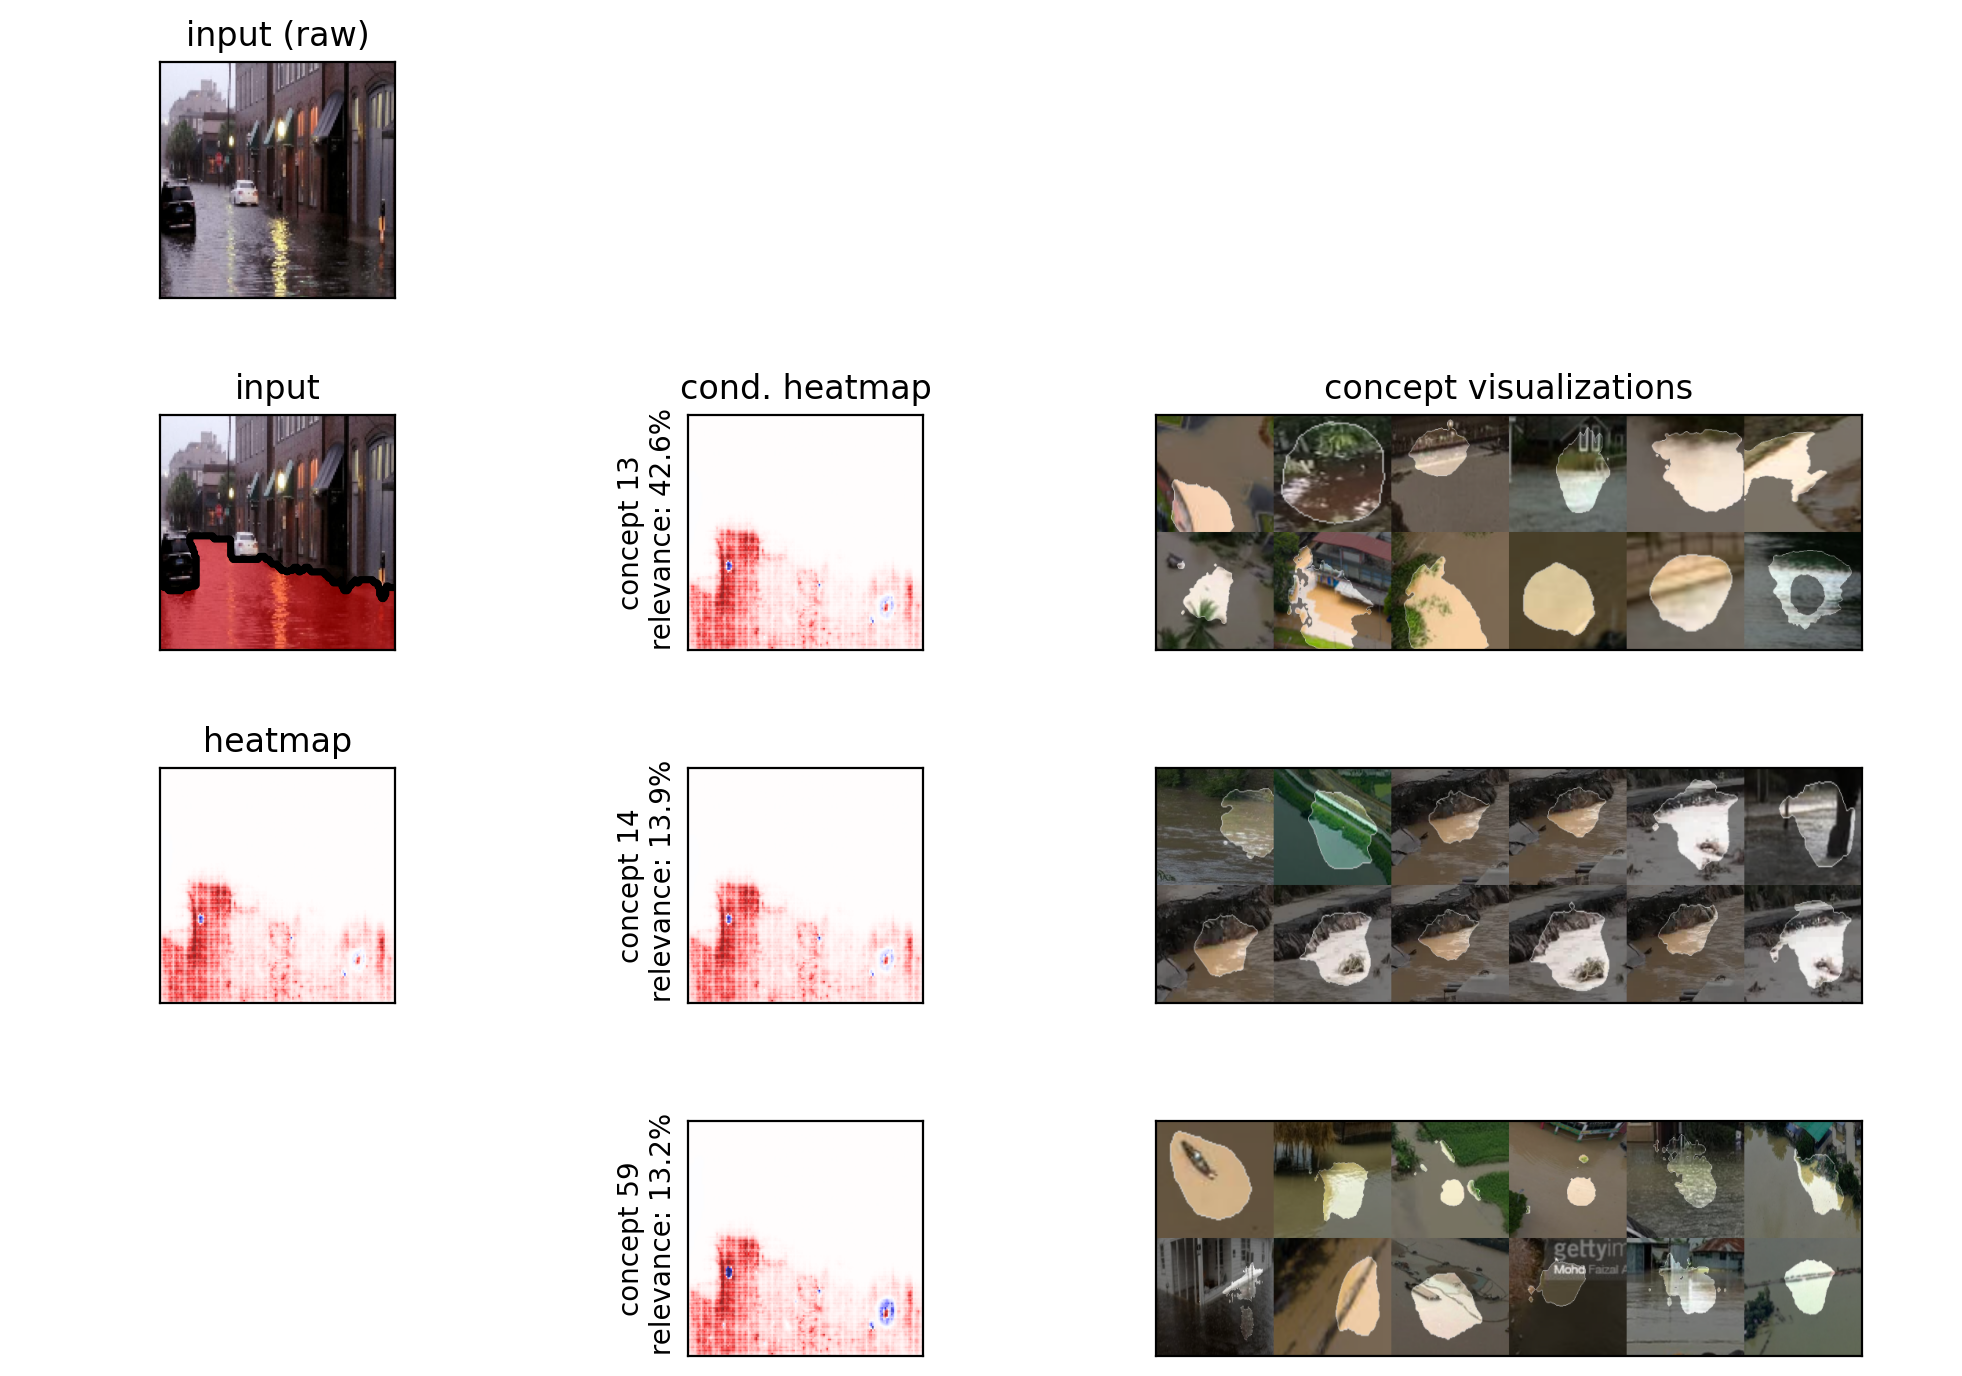

Done plotting.


In [5]:
SELECTED_LAYER = POST_MERGE_LAYERS[0]
require_crp_artifacts(CRP_OUTPUT)

plot_explanations(
    MODEL_NAME, model, dataset, SAMPLE_ID, CLASS_ID, SELECTED_LAYER,
    PREDICTION_NUM, MODE, N_CONCEPTS, N_REFIMGS,
    output_dir=str(CRP_OUTPUT),
)

## PCX explanation for one layer

In [6]:
require_crp_artifacts(CRP_OUTPUT)
require_pcx_artifacts(PCX_OUTPUT)
pcx_figure = plot_pcx_explanations(
    MODEL_NAME, model, dataset,
    sample_id=SAMPLE_ID,
    layer_name=SELECTED_LAYER,
    n_concepts=N_CONCEPTS,
    n_refimgs=N_REFIMGS,
    num_prototypes=N_PROTOTYPES,
    ref_imgs_path=str(REF_OUTPUT),
    output_dir_crp=str(CRP_OUTPUT),
    output_dir_pcx=str(PCX_OUTPUT),
)
display(pcx_figure)
plt.close(pcx_figure)

[plot_pcx_explanations] starting
[plot_pcx_explanations] sample_id=10 img.shape=(3, 720, 1280)
[plot_one_image_pcx_explanation] device=cpu, layer=dfm.conv_p.0
[attr] building attribution/composite/visualization
[attr] layer_map size=79
[data] x.shape=(1, 3, 720, 1280)
[attr] computing base attribution
[attr] base heatmap computed
[mask] building predicted mask
[mask] reverse_augmentation available, target size=(720, 1280)
[mask] resized mask -> (720, 1280)
[concepts] computing channel relevances
[concepts] channel_rels shape=(1, 128)
[concepts] topk_ind=[13, 14, 59] topk_rel=[0.4259999990463257, 0.13899999856948853, 0.13199999928474426]
[attr] computing conditional heatmaps
[refs] computing/loading reference images
[get_ref_images] start; layer=dfm.conv_p.0, n_ref=12, cache=/home/heydari/paper/Segmentation-and-Object-detection-PCX/output/ref_imgs_pidnet_postmerge/dfm.conv_p.0.h5
[get_ref_images] cache missing -> computing all
[get_ref_images] saved key=13 count=12
[get_ref_images] save

FileNotFoundError: Attributions file not found: /home/heydari/paper/Segmentation-and-Object-detection-PCX/output/pcx/pidnet_flood_postmerge/dfm.conv_p.0/attributions.npy

## Plot CRP explanations for all post-merge layers

In [ ]:
require_crp_artifacts(CRP_OUTPUT)
for layer in POST_MERGE_LAYERS:
    print(f'\n=== CRP: {layer} ===')
    plot_explanations(
        MODEL_NAME, model, dataset, SAMPLE_ID, CLASS_ID, layer,
        PREDICTION_NUM, MODE, N_CONCEPTS, N_REFIMGS,
        output_dir=str(CRP_OUTPUT),
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Plot PCX explanations for all post-merge layers

In [ ]:
require_crp_artifacts(CRP_OUTPUT)
require_pcx_artifacts(PCX_OUTPUT)
pcx_figures = {}
for layer in POST_MERGE_LAYERS:
    print(f'\n=== PCX: {layer} ===')
    figure = plot_pcx_explanations(
        MODEL_NAME, model, dataset,
        sample_id=SAMPLE_ID, layer_name=layer,
        n_concepts=N_CONCEPTS, n_refimgs=N_REFIMGS,
        num_prototypes=N_PROTOTYPES,
        ref_imgs_path=str(REF_OUTPUT),
        output_dir_crp=str(CRP_OUTPUT),
        output_dir_pcx=str(PCX_OUTPUT),
    )
    pcx_figures[layer] = figure
    display(figure)
    plt.close(figure)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Usage notes

1. Run the CRP analysis cell once with `RUN_CRP_ANALYSIS=True`.
2. Change it back to `False` for later plotting sessions.
3. Adjust `SAMPLE_ID`, `CLASS_ID`, and the concept/reference counts in the configuration cell.
4. PCX reference images are cached per layer in HDF5 files under `REF_OUTPUT`.